C:\Users\LucAA\AppData\Local\Temp\ipykernel_4140\1315768247.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  roi = img * mask3d


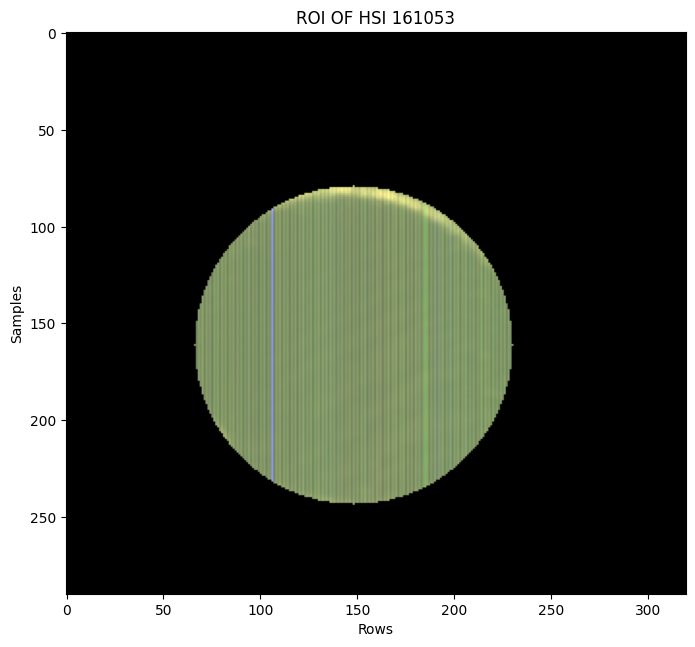

True

In [3]:
import spectral
import cv2
import numpy as np
import matplotlib.pyplot as plt

caminho =  r"C:\Users\LucAA\Documents\GitHub\IC_2025\Ic2025\data_processed\ATCC13_240506-161053.hdr"

img = spectral.open_image(caminho).load()
rgb = spectral.get_rgb(img,[50,30, 10])

gray = cv2.cvtColor((rgb *255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(gray,(7,7),2)

circles = cv2.HoughCircles(gray,cv2.HOUGH_GRADIENT,1.2,100,param1=100,param2=30,minRadius=50,maxRadius=200)
mask = np.zeros(gray.shape,dtype=np.uint8)
x,y,r= circles[0][0]
cv2.circle(mask,(int(x),int(y)),int(r),1,thickness=-1)

mask3d = np.repeat(mask[:,:,np.newaxis],img.shape[2],axis=2)
roi = img * mask3d

roi_rgb = spectral.get_rgb(roi, [50, 30, 10])
roi_rgb_norm = roi_rgb / roi_rgb.max()

altura, largura, n_bandas = img.shape
img_array = img 

n_amostras = altura * largura

# Transformar a imagem em matriz 2D (pixels x bandas)
espectros_matriz = img.reshape(n_amostras, n_bandas)

media_total = espectros_matriz.mean()
plt.figure(figsize=(8, 8))
plt.imshow(roi_rgb_norm)
plt.title("ROI OF HSI 161053")
plt.xlabel("Rows")
plt.ylabel("Samples")
plt.show()
cv2.imwrite("roi_rgb_norm.png", (roi_rgb_norm * 255).astype(np.uint8))







In [ ]:
espectros_matriz_norm = (espectros_matriz - espectros_matriz.min(axis=1, keepdims=True)) / \
                        (espectros_matriz.max(axis=1, keepdims=True) - espectros_matriz.min(axis=1, keepdims=True) + 1e-8)
#normalização